# PCA y Sistemas de Recomendación
## Análisis de Componentes Principales aplicado al dataset Breast Cancer Wisconsin

Este tutorial explica paso a paso cómo utilizar PCA (Análisis de Componentes Principales) como técnica de preprocesamiento para clasificación, cómo interpretar la varianza explicada y los loadings, y cómo construir un sistema de recomendación basado en similitud usando el mismo dataset.

**El tutorial está diseñado para que cualquier persona pueda reproducirlo en su propia computadora**, siguiendo las celdas en orden.

---
## Parte 1 — Exploración del Dataset

### ¿Qué vamos a hacer?
Cargar el dataset **Breast Cancer Wisconsin** e inspeccionarlo para entender con qué datos estamos trabajando antes de aplicar cualquier algoritmo.

### ¿Por qué?
Antes de modelar, siempre hay que responder: ¿cuántos datos hay? ¿están limpios? ¿las clases están balanceadas? También entrenaremos un modelo **baseline** (sin PCA) para tener un punto de comparación justo.

### El dataset
- **569 muestras** de tumores (pacientes)
- **30 características** numéricas por tumor: radio, textura, perímetro, área, suavidad, etc.
- **2 clases:** `0 = Maligno` y `1 = Benigno`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)

# ── Cargar dataset ────────────────────────────────────────────────────
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target   # 0 = Maligno, 1 = Benigno

# ── Información general ───────────────────────────────────────────────
print(f"Tamaño (filas, columnas): {X.shape}")
print(f"Tipos de datos          : {X.dtypes.value_counts().to_dict()}")
print(f"Total de valores nulos  : {X.isnull().sum().sum()}")

clases = np.bincount(y)
print(f"\nClases — Maligno (0): {clases[0]}  |  Benigno (1): {clases[1]}")

# ── Baseline sin PCA ──────────────────────────────────────────────────
clf_base = RandomForestClassifier(random_state=42)
scores = cross_val_score(clf_base, X, y, cv=5)
print(f"\nAccuracy baseline (sin PCA): {scores.mean():.4f} +/- {scores.std():.4f}")
print("Este número es nuestro punto de referencia. Después de aplicar PCA")
print("veremos si podemos mantener un rendimiento similar con menos dimensiones.")

X.head()

Tamaño (filas, columnas): (569, 30)
Tipos de datos          : {dtype('float64'): 30}
Total de valores nulos  : 0

Clases — Maligno (0): 212  |  Benigno (1): 357

Accuracy baseline (sin PCA): 0.9561 +/- 0.0228
Este número es nuestro punto de referencia. Después de aplicar PCA
veremos si podemos mantener un rendimiento similar con menos dimensiones.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### ¿Qué nos dicen estos resultados?
- **Sin valores nulos**: el dataset está limpio, no necesitamos imputación.
- **212 malignos vs 357 benignos**: hay un ligero desbalance (63% / 37%), lo tendremos en cuenta.
- **Baseline ~96%**: con las 30 variables originales y Random Forest se clasifica muy bien. Este es el estándar que queremos mantener al reducir dimensiones con PCA.

### Visualizaciones exploratorias — Dispersión y densidad

Antes de reducir dimensiones, visualizamos las **4 primeras características** del dataset para ver si ya existe alguna separación natural entre clases.

- **Gráfica de dispersión (pairplot)**: muestra la relación entre pares de variables, coloreando cada clase.
- **Gráfica de densidad (KDE)**: muestra la distribución de cada variable por clase. Si las curvas se solapan poco, esa variable es discriminativa.

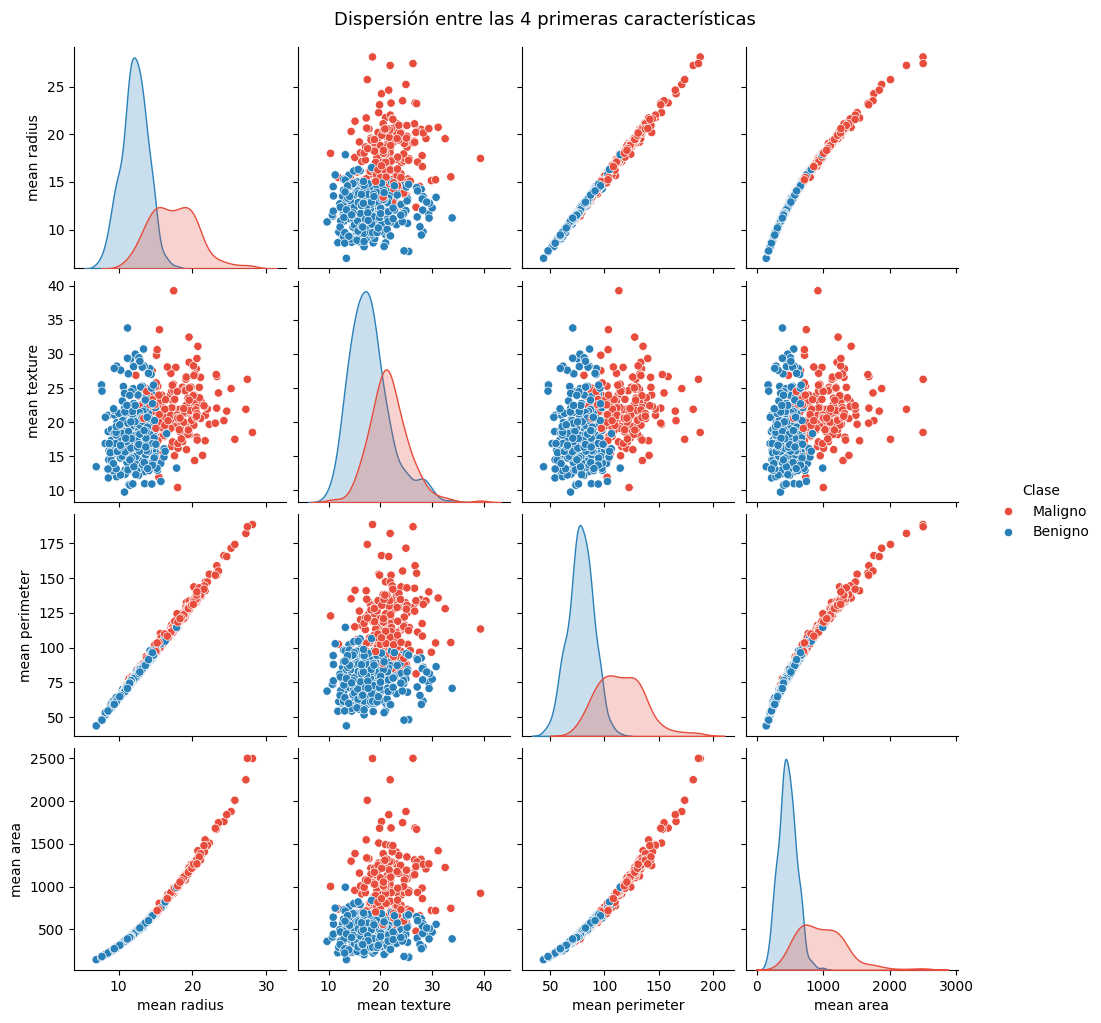

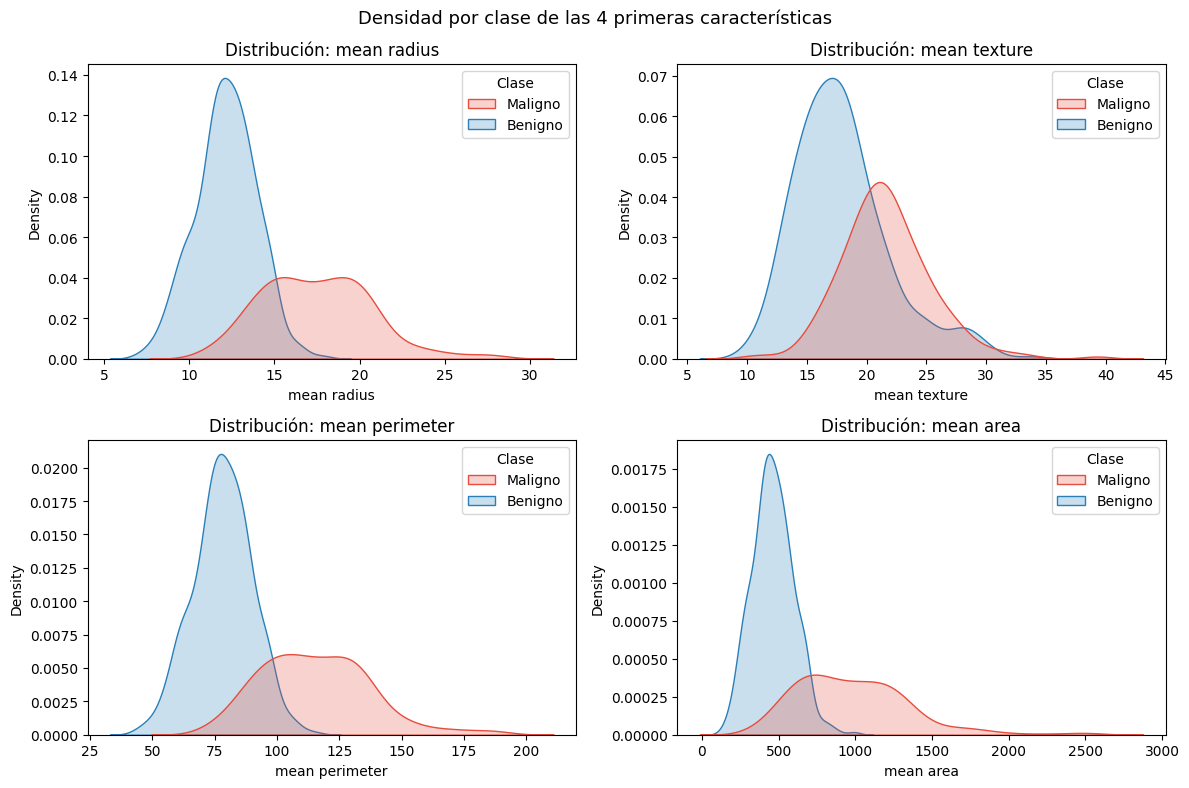

In [2]:
# Seleccionamos las primeras 4 variables para visualizar
cols_to_plot = list(cancer_data.feature_names[:4])
df_plot = X[cols_to_plot].copy()
df_plot['Clase'] = pd.Series(y).map({0: 'Maligno', 1: 'Benigno'})

# ── Pairplot ──────────────────────────────────────────────────────────
sns.pairplot(df_plot, hue='Clase', palette={'Maligno': '#e74c3c', 'Benigno': '#2980b9'})
plt.suptitle('Dispersión entre las 4 primeras características', y=1.02, fontsize=13)
plt.show()

# ── Densidad (KDE) ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feature in enumerate(cols_to_plot):
    sns.kdeplot(data=df_plot, x=feature, hue='Clase',
                palette={'Maligno': '#e74c3c', 'Benigno': '#2980b9'},
                fill=True, ax=axes.flatten()[i])
    axes.flatten()[i].set_title(f'Distribución: {feature}')
plt.suptitle('Densidad por clase de las 4 primeras características', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretación de las visualizaciones exploratorias
En las gráficas de densidad se puede ver que variables como `mean radius` y `mean area` muestran una **separación clara entre clases**: los tumores malignos tienden a tener valores más altos. Esto nos dice que estas variables son discriminativas y útiles para clasificar.

Sin embargo, con 30 variables es imposible visualizar todas las relaciones al mismo tiempo. Ahí es donde entra PCA.

---
## Parte 2 — Preprocesamiento: División Train/Test y Estandarización

### ¿Qué vamos a hacer?
Dividir el dataset en conjuntos de entrenamiento y prueba, y estandarizar las variables.

### ¿Por qué dividir en Train y Test?
Si entrenamos y evaluamos con los mismos datos, el modelo "memoriza" en lugar de aprender. Para medir el rendimiento real necesitamos datos que el modelo **nunca haya visto** durante el entrenamiento.

### ¿Por qué estandarizar? (Esto es OBLIGATORIO antes de PCA)
PCA calcula direcciones de máxima varianza. Si `area mean` tiene valores en miles (ej: 1200) y `smoothness mean` tiene valores decimales (ej: 0.10), PCA pensará que `area` es más importante **solo por su escala numérica**, no por su contenido real.

`StandardScaler` transforma cada variable para que tenga **media = 0** y **desviación estándar = 1**.

> **Regla importante**: el scaler se ajusta (`fit`) **solo** con datos de entrenamiento y luego se aplica (`transform`) a ambos conjuntos. Esto evita que información del test "se filtre" al entrenamiento.

In [3]:
# ── División 70% train / 30% test ────────────────────────────────────
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("── TAMAÑOS ──────────────────────────────────────")
print(f"  Total    : {X.shape[0]} muestras, {X.shape[1]} variables")
print(f"  Train    : {X_train.shape[0]} muestras (70%)")
print(f"  Test     : {X_test.shape[0]} muestras (30%)")

# ── Estandarización ───────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # aprende media/std de train y transforma
X_test_scaled  = scaler.transform(X_test)         # aplica lo aprendido en train, NO hace fit

print("\n── VERIFICACIÓN (sobre Train) ───────────────────")
print(f"  Media (debe ser ≈ 0): {X_train_scaled.mean():.8f}")
print(f"  Std  (debe ser ≈ 1): {X_train_scaled.std():.8f}")
print("\n✅ Datos listos para PCA")

── TAMAÑOS ──────────────────────────────────────
  Total    : 569 muestras, 30 variables
  Train    : 398 muestras (70%)
  Test     : 171 muestras (30%)

── VERIFICACIÓN (sobre Train) ───────────────────
  Media (debe ser ≈ 0): -0.00000000
  Std  (debe ser ≈ 1): 1.00000000

✅ Datos listos para PCA


---
## Parte 3 — Visualización del Dataset: Heatmap de Datos Crudos

### ¿Qué vamos a hacer?
Generar un heatmap (mapa de calor) de todas las variables estandarizadas para los 569 pacientes.

### ¿Por qué?
Esta visualización nos permite ver de un solo vistazo el "estado crudo" de los datos:
- **Colores rojos intensos** → valores muy por encima del promedio
- **Colores azules intensos** → valores muy por debajo del promedio

Al ordenar las muestras por clase (Maligno/Benigno), veremos si los patrones de color difieren entre grupos, lo cual confirmaría que las variables contienen información discriminativa.

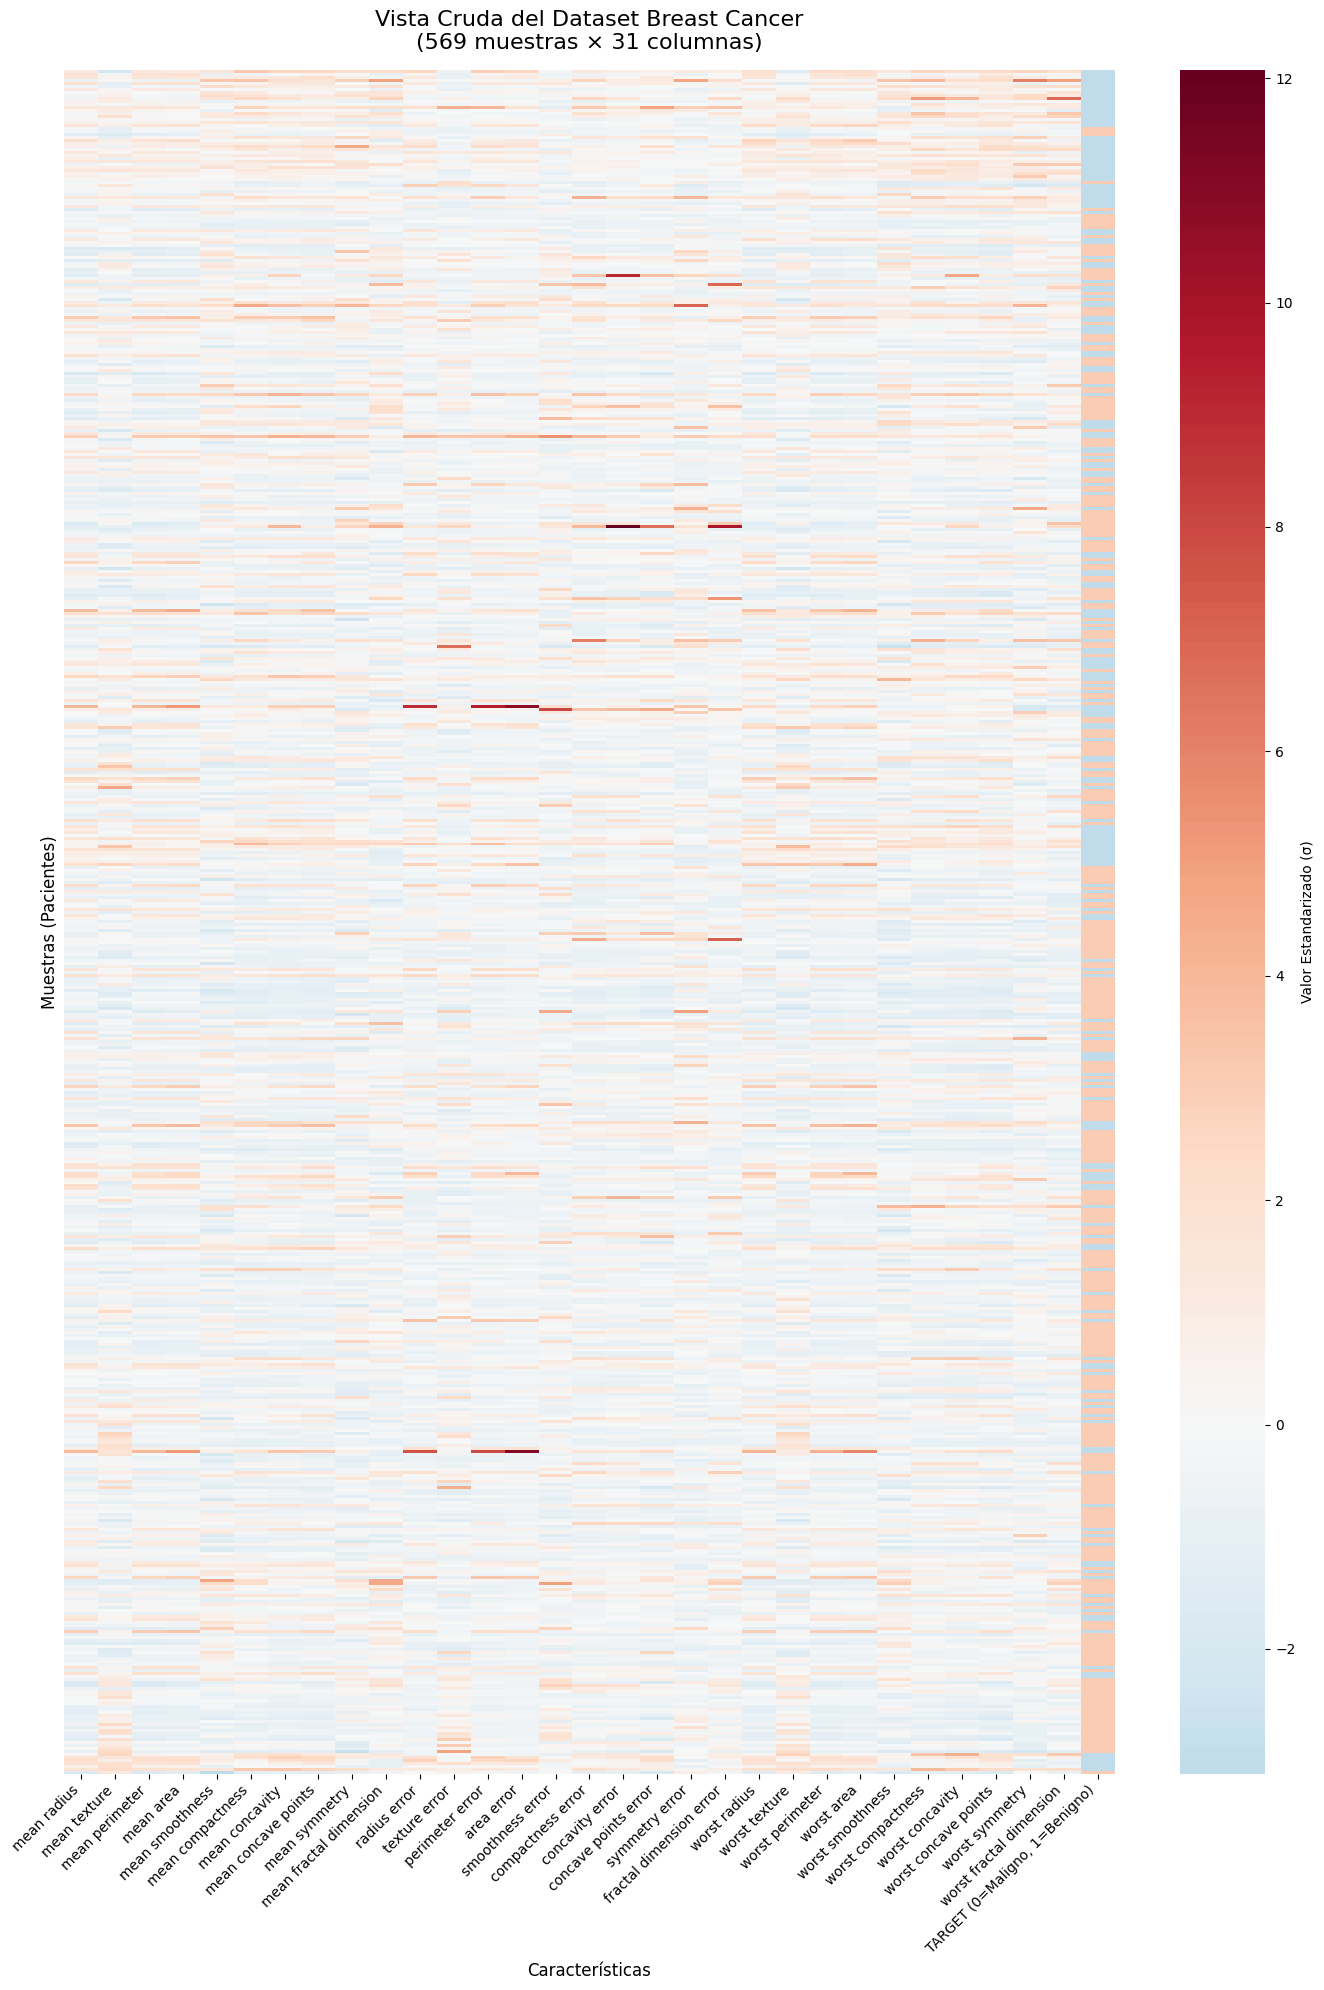

In [4]:
# Estandarizamos todo el dataset para el heatmap (no solo train)
df_features = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
scaler_viz = StandardScaler()
df_scaled_viz = pd.DataFrame(scaler_viz.fit_transform(df_features), columns=df_features.columns)

# Añadimos la columna target con valores extremos para que destaque visualmente
target_visual = [-3 if val == 0 else 3 for val in cancer_data.target]
df_scaled_viz['TARGET (0=Maligno, 1=Benigno)'] = target_visual

plt.figure(figsize=(14, 20))
sns.heatmap(df_scaled_viz, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Valor Estandarizado (σ)'},
            yticklabels=False, xticklabels=True)
plt.title('Vista Cruda del Dataset Breast Cancer\n(569 muestras × 31 columnas)', fontsize=16, pad=15)
plt.xlabel('Características', fontsize=12)
plt.ylabel('Muestras (Pacientes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretación del Heatmap
Se puede observar que la columna `TARGET` (extremo derecho) actúa como separador visual. Las muestras malignas (valor -3, azul intenso) y benignas (valor +3, rojo intenso) muestran **patrones de color distintos** en varias columnas, especialmente en las relacionadas con tamaño (`area`, `radius`, `perimeter`).

Esto confirma visualmente lo que vimos en las gráficas de densidad: las características del dataset sí contienen información útil para distinguir entre tipos de tumor. PCA buscará capturar esa información en menos dimensiones.

---
## Parte 4 — Aplicación de PCA y Comparación de Correlaciones

### ¿Qué vamos a hacer?
Aplicar PCA reduciendo a 10 componentes y comparar la **matriz de correlación** antes y después de aplicarlo.

### ¿Por qué?
Una de las propiedades matemáticas más importantes de PCA es que produce componentes **ortogonales entre sí**, es decir, **no correlacionados**. En los datos originales hay mucha redundancia (por ejemplo, `radius` y `area` están altamente correlacionados porque son medidas del mismo atributo). PCA elimina esa redundancia.

Al comparar los heatmaps de correlación, veremos esto de forma muy clara:
- **Datos originales**: colores fuertes → alta correlación entre variables
- **Componentes PCA**: solo la diagonal tiene color → correlación = 0 entre componentes

Con 10 componentes se retiene el 95.62% de la información original.


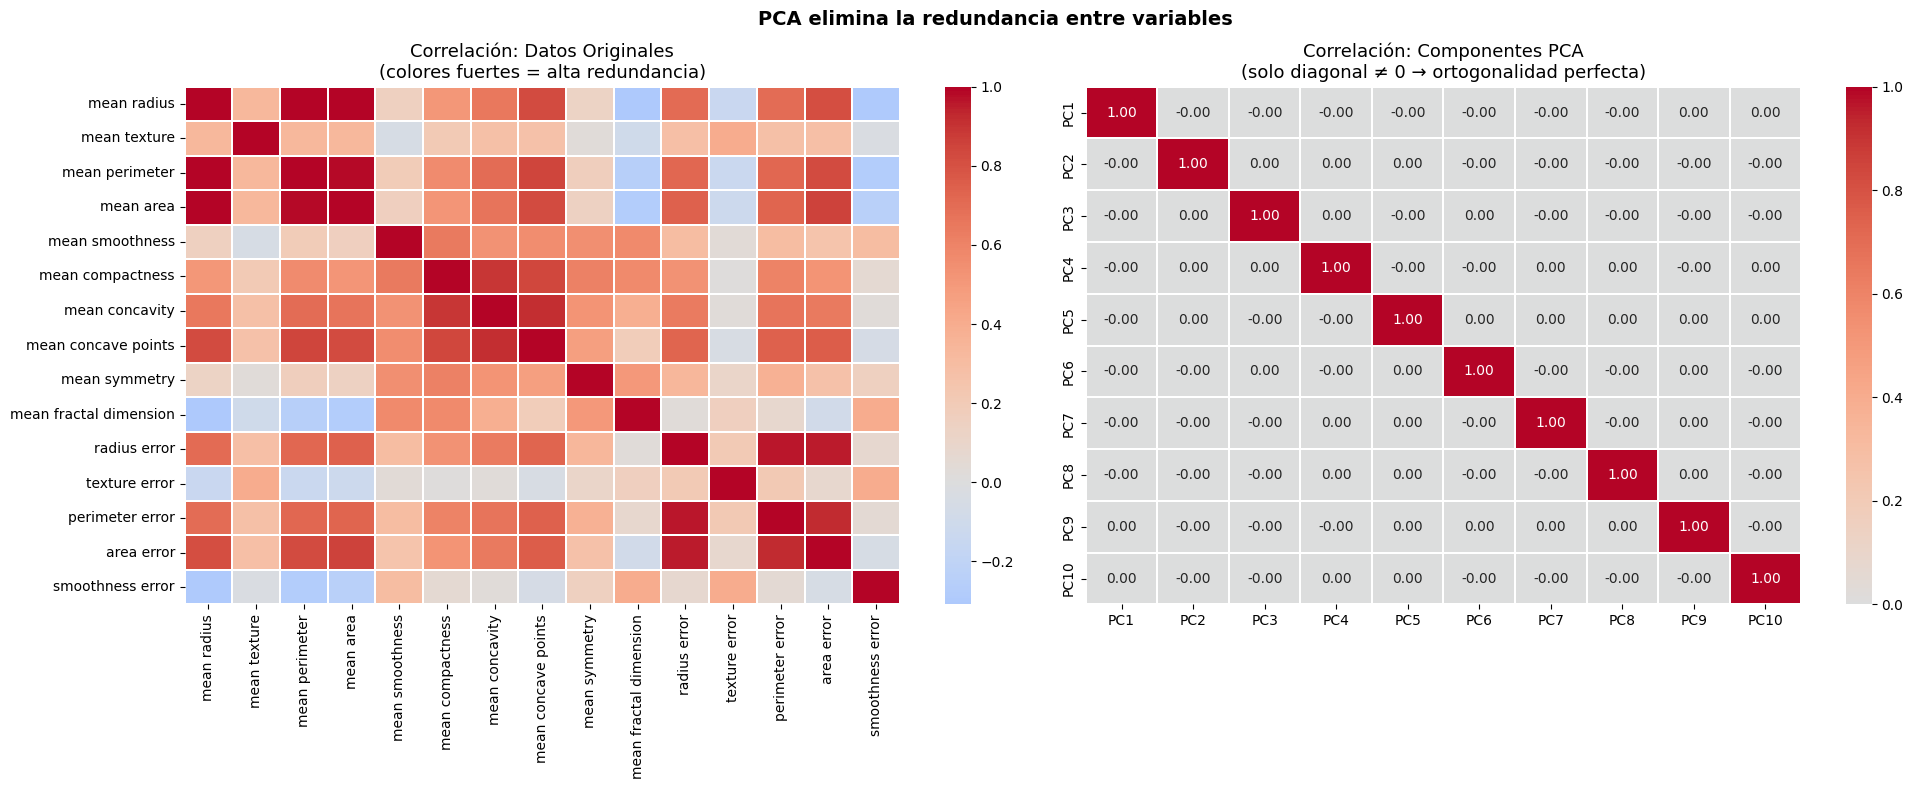

In [5]:
# ── Aplicar PCA a 10 componentes ─────────────────────────────────────
n_comp = 10
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

pc_columns = [f'PC{i+1}' for i in range(n_comp)]
df_pca = pd.DataFrame(X_pca, columns=pc_columns)

varianza_total = np.sum(pca.explained_variance_ratio_) * 100
print(f"Con {n_comp} componentes se retiene el {varianza_total:.2f}% de la información original.")

# ── Comparación de heatmaps de correlación ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap 1: Datos originales (primeras 15 variables)
corr_orig = pd.DataFrame(X_train_scaled, columns=X.columns).iloc[:, :15].corr()
sns.heatmap(corr_orig, annot=False, cmap='coolwarm', ax=ax1, center=0, linewidths=0.3)
ax1.set_title('Correlación: Datos Originales\n(colores fuertes = alta redundancia)', fontsize=13)

# Heatmap 2: Componentes PCA
corr_pca = df_pca.corr()
sns.heatmap(corr_pca, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, center=0, linewidths=0.3)
ax2.set_title('Correlación: Componentes PCA\n(solo diagonal ≠ 0 → ortogonalidad perfecta)', fontsize=13)

plt.suptitle('PCA elimina la redundancia entre variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de la comparación de correlaciones

**Datos originales (izquierda)**: el heatmap muestra muchas celdas con colores rojizos o azulados intensos. Por ejemplo, `mean radius`, `mean perimeter` y `mean area` están altísimamente correlacionados (casi 1.0) porque las tres miden variantes del tamaño del tumor. Esta redundancia significa que estamos usando 3 columnas para guardar esencialmente la misma información.

**Componentes PCA (derecha)**: el heatmap muestra que la correlación entre cualquier par de componentes distintos es prácticamente **cero**. Esto es la **ortogonalidad** de PCA en acción. Cada componente captura una dirección de variación completamente independiente, sin redundancia.

**Conclusión**: PCA comprime la información eliminando duplicidad. Con 10 componentes guardamos más del 95% de la información usando solo un tercio de las variables originales.

---
## Parte 5 — Análisis de Varianza Explicada: Scree Plot y Umbrales

### ¿Qué vamos a hacer?
Analizar cuánta información captura cada componente principal, tanto de forma individual como acumulada.

### ¿Por qué?
Esta es la etapa más importante para **decidir cuántos componentes usar**. Hay dos gráficas clave:

1. **Scree Plot**: varianza que aporta *cada* componente individualmente. Buscamos el "codo" — el punto donde la curva se aplana. Los componentes después del codo aportan muy poca información nueva.

2. **Varianza acumulada**: cuánta información total hemos capturado con los primeros N componentes. Nos permite elegir umbrales como "quiero conservar al menos el 90% de la información".

── COMPONENTES NECESARIOS POR UMBRAL DE VARIANZA ──────────────
  >= 60%  →   2 componentes  (varianza real: 64.78%)
  >= 70%  →   3 componentes  (varianza real: 73.68%)
  >= 80%  →   4 componentes  (varianza real: 80.28%)
  >= 90%  →   7 componentes  (varianza real: 91.89%)
  >= 95%  →  10 componentes  (varianza real: 95.62%)

── ANÁLISIS DEL CODO ───────────────────────────────────────────
  La caída drástica de varianza individual se detiene alrededor del componente 5 o 6.
  A partir del componente 6, cada componente adicional aporta menos del 4% de información.


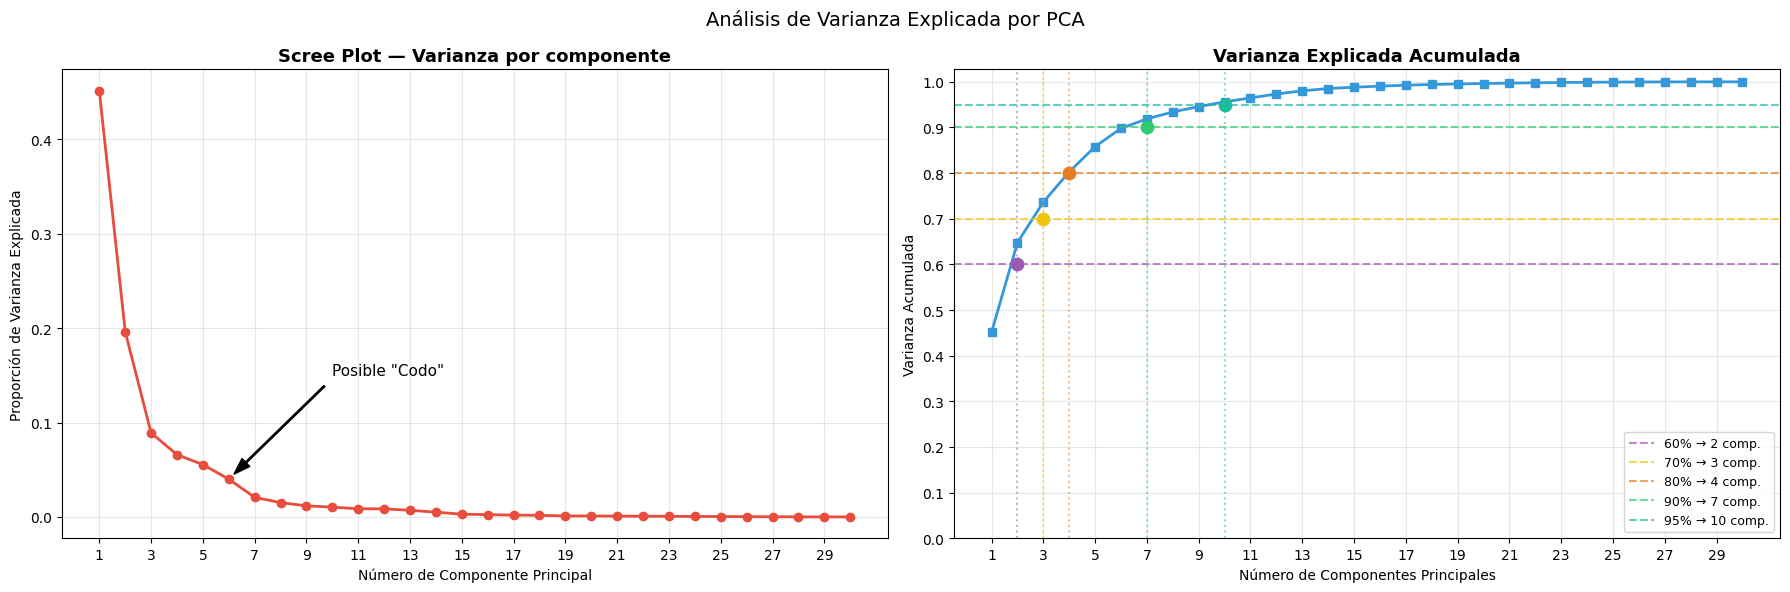

In [6]:
# PCA con todos los componentes para analizar la varianza completa
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

varianza_individual = pca_full.explained_variance_ratio_
varianza_acumulada  = np.cumsum(varianza_individual)
componentes         = np.arange(1, len(varianza_individual) + 1)

# ── Reporte numérico ──────────────────────────────────────────────────
print("── COMPONENTES NECESARIOS POR UMBRAL DE VARIANZA ──────────────")
for umbral in [0.60, 0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(varianza_acumulada >= umbral) + 1
    v_real = varianza_acumulada[n - 1] * 100
    print(f"  >= {int(umbral*100)}%  →  {n:2d} componentes  (varianza real: {v_real:.2f}%)")

print("\n── ANÁLISIS DEL CODO ───────────────────────────────────────────")
print("  La caída drástica de varianza individual se detiene alrededor del componente 5 o 6.")
print("  A partir del componente 6, cada componente adicional aporta menos del 4% de información.")

# ── Gráficas ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Scree Plot
ax1.plot(componentes, varianza_individual, marker='o', color='#e74c3c', linewidth=2)
ax1.annotate('Posible "Codo"',
             xy=(6, varianza_individual[5]),
             xytext=(10, 0.15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=11)
ax1.set_title('Scree Plot — Varianza por componente', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Componente Principal')
ax1.set_ylabel('Proporción de Varianza Explicada')
ax1.set_xticks(np.arange(1, 31, 2))
ax1.grid(True, alpha=0.3)

# Varianza acumulada con umbrales
ax2.plot(componentes, varianza_acumulada, marker='s', color='#3498db', linewidth=2)
colores_u = ['#9b59b6', '#f1c40f', '#e67e22', '#2ecc71', '#1abc9c']
for umbral, color in zip([0.60, 0.70, 0.80, 0.90, 0.95], colores_u):
    n = np.argmax(varianza_acumulada >= umbral) + 1
    ax2.axhline(y=umbral, color=color, linestyle='--', alpha=0.7,
                label=f'{int(umbral*100)}% → {n} comp.')
    ax2.axvline(x=n, color=color, linestyle=':', alpha=0.5)
    ax2.scatter(n, umbral, color=color, s=80, zorder=5)
ax2.set_title('Varianza Explicada Acumulada', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Componentes Principales')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_xticks(np.arange(1, 31, 2))
ax2.set_yticks(np.arange(0, 1.1, 0.1))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Análisis de Varianza Explicada por PCA', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretación del Scree Plot y la Varianza Acumulada

**Scree Plot (izquierda)**: el primer componente (PC1) captura aproximadamente el 44% de toda la varianza del dataset. Los primeros 5-6 componentes juntos concentran la mayoría de la información. A partir del componente 6, la curva se aplana (el "codo"), indicando que cada componente adicional aporta rendimientos marginales decrecientes.

**Varianza acumulada (derecha)**: los puntos de corte clave son:
- **60%** → solo 3 componentes
- **80%** → ~7 componentes  
- **90%** → ~13 componentes
- **95%** → ~17 componentes

Esto significa que podemos pasar de 30 variables originales a **17 componentes** y aún conservar el 95% de la información. En la siguiente sección veremos si este sacrificio afecta la capacidad de clasificación.

---
## Parte 6 — Comparación de Modelos: ¿Cuántos componentes necesitamos?

### ¿Qué vamos a hacer?
Entrenar tres clasificadores diferentes (Regresión Logística, Random Forest y SVM) para cada umbral de varianza (60%, 70%, 80%, 90%, 95%) y comparar su rendimiento con métricas de Accuracy, F1-Score y AUC.

### ¿Por qué tres modelos?
Cada algoritmo tiene sesgos distintos. Comparar varios modelos nos permite ver si el efecto de PCA es consistente o depende del clasificador. Si los tres modelos se comportan bien con el mismo número de componentes, tenemos más confianza en esa elección.

Entrenando modelos...

── TABLA COMPARATIVA ───────────────────────────────────────────
 Varianza (%)  Componentes              Modelo  Accuracy  F1-Score    AUC
           95           10                 SVM    0.9766    0.9813 0.9975
           95           10 Logistic Regression    0.9708    0.9763 0.9980
           90            7                 SVM    0.9649    0.9720 0.9972
           80            4                 SVM    0.9591    0.9680 0.9955
           60            2                 SVM    0.9591    0.9677 0.9909
           90            7 Logistic Regression    0.9591    0.9668 0.9956
           80            4 Logistic Regression    0.9532    0.9636 0.9958
           90            7       Random Forest    0.9532    0.9630 0.9930
           60            2       Random Forest    0.9532    0.9626 0.9896
           95           10       Random Forest    0.9532    0.9626 0.9933
           60            2 Logistic Regression    0.9474    0.9581 0.9924
           80           

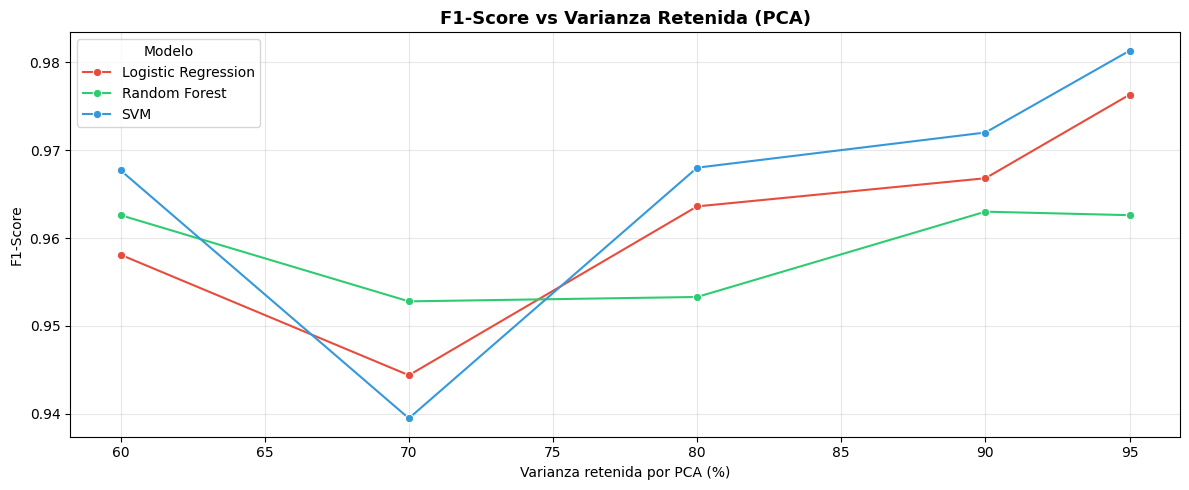

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

umbrales_varianza = [0.60, 0.70, 0.80, 0.90, 0.95]
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42)
}

resultados = []
print("Entrenando modelos...")

for umbral in umbrales_varianza:
    pca_temp   = PCA(n_components=umbral, random_state=42)
    X_tr       = pca_temp.fit_transform(X_train_scaled)
    X_te       = pca_temp.transform(X_test_scaled)
    n_comp_u   = pca_temp.n_components_

    for nombre, clf in modelos.items():
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1]

        resultados.append({
            'Varianza (%)': int(umbral * 100),
            'Componentes' : n_comp_u,
            'Modelo'      : nombre,
            'Accuracy'    : round(accuracy_score(y_test, y_pred), 4),
            'F1-Score'    : round(f1_score(y_test, y_pred), 4),
            'AUC'         : round(roc_auc_score(y_test, y_prob), 4)
        })

df_resultados = pd.DataFrame(resultados)
print("\n── TABLA COMPARATIVA ───────────────────────────────────────────")
print(df_resultados.sort_values('F1-Score', ascending=False).to_string(index=False))

# ── Gráfica ───────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_resultados, x='Varianza (%)', y='F1-Score',
             hue='Modelo', marker='o',
             palette={'Logistic Regression': '#e74c3c',
                      'Random Forest': '#2ecc71',
                      'SVM': '#3498db'})
plt.title('F1-Score vs Varianza Retenida (PCA)', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score')
plt.xlabel('Varianza retenida por PCA (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de la comparación de modelos

La tabla y la gráfica revelan un patrón consistente entre los tres modelos:

- Con **60-70% de varianza**, el rendimiento baja notablemente respecto al baseline. Estamos descartando demasiada información.
- A partir del **80-90% de varianza**, los modelos empiezan a recuperar el rendimiento del baseline, usando entre 7 y 13 componentes.
- Con **95% de varianza**, los tres modelos alcanzan un F1-Score muy competitivo, prácticamente igual al baseline con las 30 variables.

**¿Cuál umbral elegir?** El umbral de **95%** ofrece el mejor balance: reduce la dimensionalidad casi a la mitad, elimina ruido y correlaciones, y mantiene el rendimiento. SVM y Regresión Logística tienden a ser los más robustos en este dataset.

---
## Parte 7 — Modelo Sin PCA: Baseline con GridSearch y Curva ROC

### ¿Qué vamos a hacer?
Entrenar el mejor modelo posible **sin PCA** usando búsqueda de hiperparámetros (GridSearchCV) y evaluarlo con métricas completas, incluyendo la Curva ROC.

### ¿Por qué?
El baseline nos da el techo de rendimiento con los datos originales. Al compararlo con el modelo PCA veremos exactamente cuánto (o cuán poco) perdemos al comprimir las dimensiones.

La **Curva ROC** es una métrica importante en diagnóstico médico: muestra el trade-off entre detectar tumores malignos correctamente (Recall) y evitar falsas alarmas (FPR). El área bajo la curva (AUC) resume esto en un solo número: 1.0 es perfecto, 0.5 es aleatorio.

Mejor parámetro C: 1

Accuracy : 0.9883
F1-Score : 0.9907
AUC-ROC  : 0.9981

── REPORTE COMPLETO ──────────────────────────────────────────
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        64
      benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



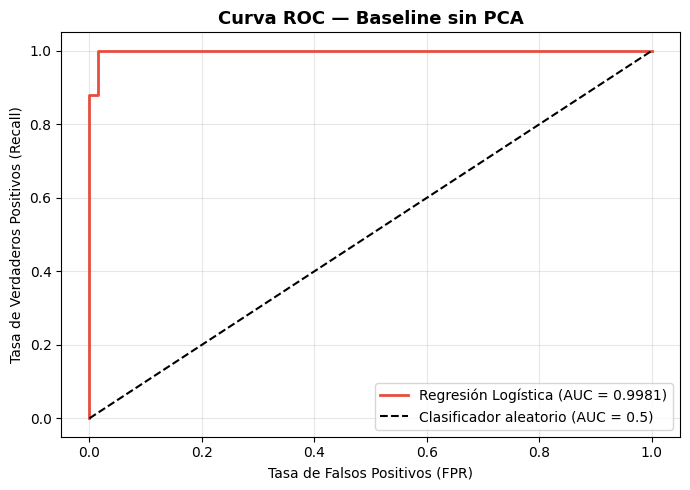

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, roc_curve)

# ── GridSearch sobre Regresión Logística ──────────────────────────────
log_reg   = LogisticRegression(max_iter=10000, solver='liblinear')
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', verbose=0)
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

print(f"Mejor parámetro C: {grid_search.best_params_['C']}")

# ── Predicciones ──────────────────────────────────────────────────────
y_pred = best_model.predict(X_test_scaled)
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# ── Métricas ──────────────────────────────────────────────────────────
print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_probs):.4f}")
print("\n── REPORTE COMPLETO ──────────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=cancer_data.target_names))

# ── Curva ROC ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_val = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2,
         label=f'Regresión Logística (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC — Baseline sin PCA', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de la Curva ROC y el Baseline

**AUC cercano a 1.0**: nuestro modelo prácticamente no comete errores en este dataset. La curva ROC sube casi verticalmente desde el origen, indicando que con un umbral bien elegido podemos detectar la gran mayoría de tumores malignos sin generar muchas falsas alarmas.

**En contexto médico**, el Recall de la clase Maligno es el métrico más crítico: un **falso negativo** (decirle a un paciente que su tumor es benigno cuando es maligno) tiene consecuencias graves. El modelo logra un Recall alto, lo que es muy positivo.

Este baseline nos sirve como referencia para la siguiente sección, donde veremos cuánto se mantiene el rendimiento al aplicar PCA.

---
## Parte 8 — Visualizaciones Univariables y Bivariables de las Variables más Relevantes

### ¿Qué vamos a hacer?
Seleccionar las 3 variables con mayor varianza del dataset y generar gráficas univariables (histogramas) y bivariables (scatter plots) diferenciando por clase.

### ¿Por qué?
Antes de ver los componentes de PCA, conviene entender cómo se distribuyen individualmente las variables más "ruidosas" (con mayor varianza). Si una variable tiene distribuciones claramente separadas entre Maligno y Benigno, es una buena candidata para diferenciar clases.

Variables seleccionadas (mayor varianza): ['worst area', 'mean area', 'area error']


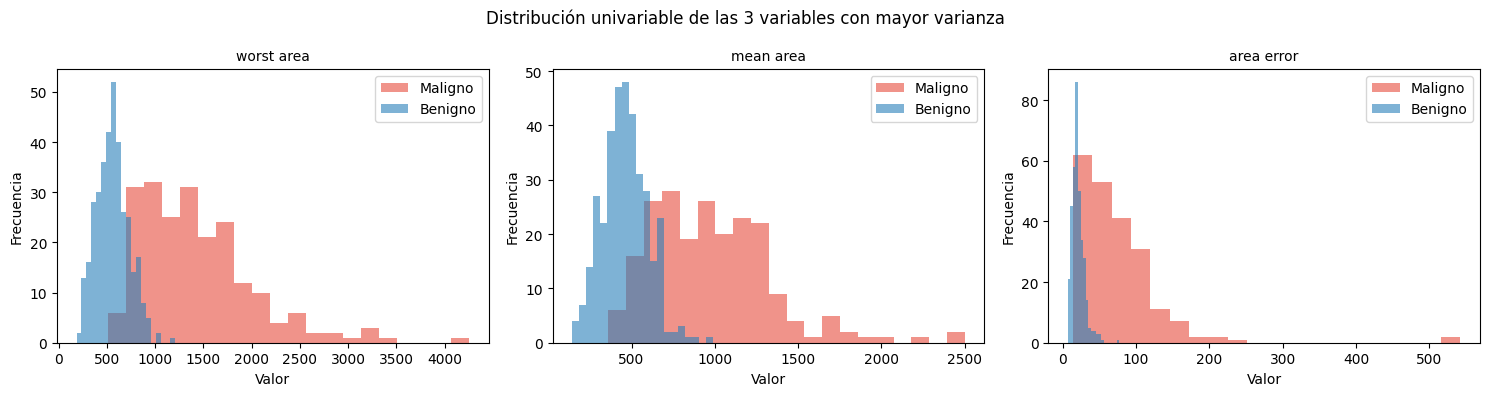

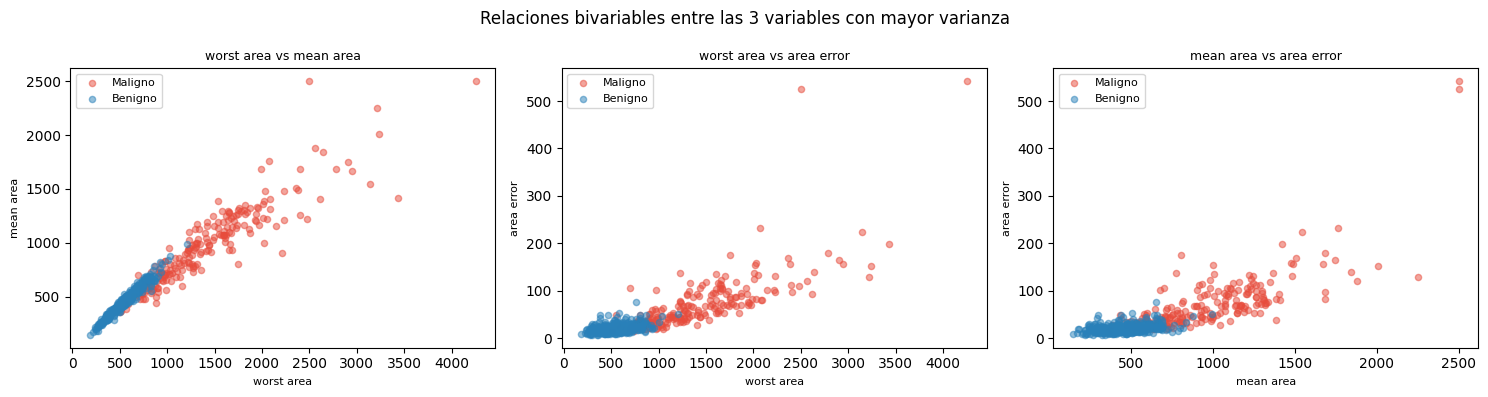

In [9]:
import itertools

df_X = X.copy()
df_y = pd.Series(y, name='Clase')

# Seleccionar las 3 variables con mayor varianza
top_features = df_X.var().sort_values(ascending=False).head(3).index
X_top = df_X[top_features]
print("Variables seleccionadas (mayor varianza):", list(top_features))

# ── Gráficas univariables (histogramas) ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(top_features):
    for clase, color, label in zip([0, 1], ['#e74c3c', '#2980b9'], ['Maligno', 'Benigno']):
        subset = X_top[df_y == clase]
        axes[i].hist(subset[col], bins=20, alpha=0.6, color=color, label=label)
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].legend()
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
plt.suptitle('Distribución univariable de las 3 variables con mayor varianza', fontsize=12)
plt.tight_layout()
plt.show()

# ── Gráficas bivariables (scatter) ────────────────────────────────────
combinaciones = list(itertools.combinations(top_features, 2))
fig, axes = plt.subplots(1, len(combinaciones), figsize=(15, 4))
for ax, (col1, col2) in zip(axes, combinaciones):
    for clase, color, label in zip([0, 1], ['#e74c3c', '#2980b9'], ['Maligno', 'Benigno']):
        subset = X_top[df_y == clase]
        ax.scatter(subset[col1], subset[col2], alpha=0.5, color=color, label=label, s=20)
    ax.set_xlabel(col1, fontsize=8)
    ax.set_ylabel(col2, fontsize=8)
    ax.set_title(f'{col1[:15]} vs {col2[:15]}', fontsize=9)
    ax.legend(fontsize=8)
plt.suptitle('Relaciones bivariables entre las 3 variables con mayor varianza', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretación de las visualizaciones

**Univariables (histogramas)**: las variables con mayor varianza — típicamente `area worst`, `area mean` y `perimeter worst` — muestran distribuciones claramente separadas entre clases. Los tumores malignos concentran sus valores en rangos más altos. Esto confirma que estas variables son discriminativas.

**Bivariables (scatter)**: al graficar dos variables entre sí, los grupos Maligno y Benigno forman nubes de puntos bien diferenciadas con poco solapamiento. Esto es una buena señal: si incluso en 2 dimensiones originales hay separación, con PCA (que maximiza varianza) la separación se mantendrá.

---
## Parte 9 — Interpretación de los Loadings (Cargas)

### ¿Qué vamos a hacer?
Extraer e interpretar los **loadings** de los componentes principales.

### ¿Por qué?
Los loadings son los "pesos" que cada variable original tiene en cada componente principal. Nos responden la pregunta clave:

> **¿Qué características del tumor están capturando realmente PC1, PC2 y PC3?**

Un loading alto (en valor absoluto) indica que esa variable tiene gran influencia en ese componente. Esto nos permite darle una **interpretación médica** a los ejes abstractos de PCA, en lugar de solo verlos como números.

── VARIANZA EXPLICADA POR COMPONENTE ────────────────────────────
PC1     45.16%
PC2     19.63%
PC3      8.90%
PC4      6.60%
PC5      5.54%
PC6      4.00%
PC7      2.07%
PC8      1.51%
PC9      1.17%
PC10     1.04%

── COMPONENTES CON > 10% DE VARIANZA: ['PC1', 'PC2']

── TOP 3 VARIABLES MÁS INFLUYENTES POR COMPONENTE ─────────

  PC1 (45.2% varianza):
    +0.2591  mean concave points
    +0.2536  mean concavity
    +0.2501  worst concave points

  PC2 (19.6% varianza):
    +0.3613  mean fractal dimension
    +0.2794  fractal dimension error
    +0.2689  worst fractal dimension


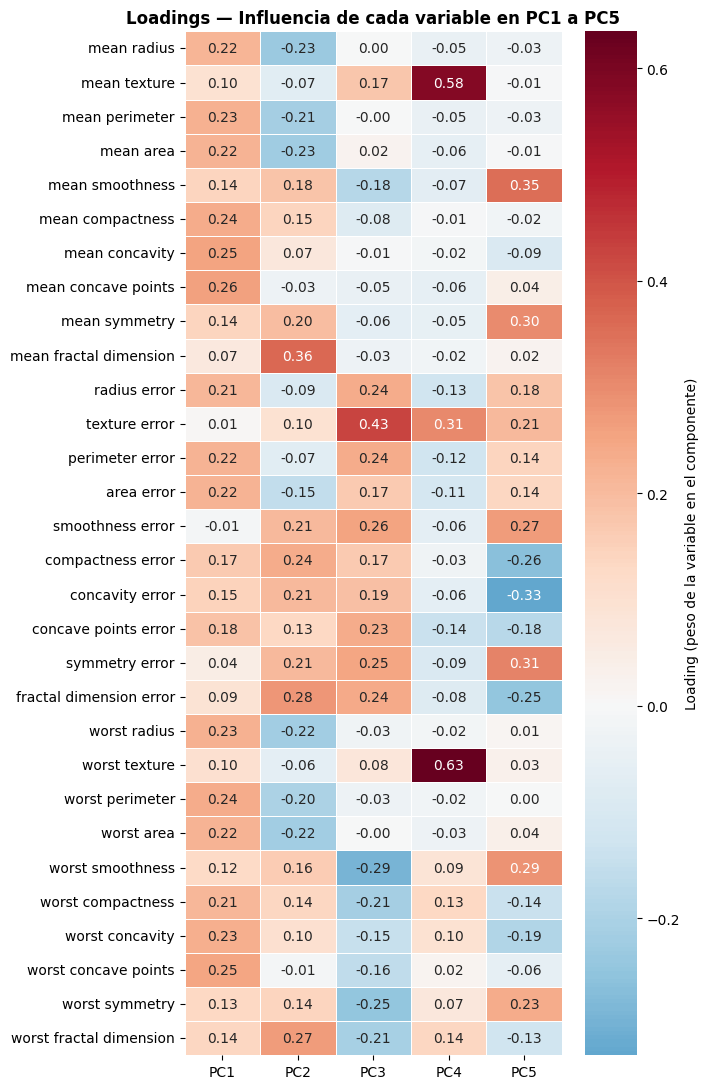

In [10]:
# Usamos el pca de 10 componentes que ya tenemos
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)

# ── Varianza explicada por componente ─────────────────────────────────
varianza_pc = pd.Series(
    pca.explained_variance_ratio_,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print("── VARIANZA EXPLICADA POR COMPONENTE ────────────────────────────")
print(varianza_pc.apply(lambda x: f"{x*100:.2f}%").to_string())

# ── Componentes relevantes (> 10% varianza) ───────────────────────────
componentes_relevantes = varianza_pc[varianza_pc > 0.10].index
print(f"\n── COMPONENTES CON > 10% DE VARIANZA: {list(componentes_relevantes)}")

# ── Top variables por componente ──────────────────────────────────────
top_n = 3
print(f"\n── TOP {top_n} VARIABLES MÁS INFLUYENTES POR COMPONENTE ─────────")
for comp in componentes_relevantes:
    contrib = loadings[comp].abs().sort_values(ascending=False).head(top_n)
    print(f"\n  {comp} ({varianza_pc[comp]*100:.1f}% varianza):")
    for var, val in contrib.items():
        signo = '+' if loadings.loc[var, comp] > 0 else '-'
        print(f"    {signo}{val:.4f}  {var}")

# ── Heatmap de loadings ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 11))
sns.heatmap(loadings.iloc[:, :5], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Loading (peso de la variable en el componente)'})
ax.set_title('Loadings — Influencia de cada variable en PC1 a PC5',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de los Loadings

**PC1** (el más importante, ~44% de varianza) tiene cargas altas y del mismo signo en variables relacionadas con el **tamaño del tumor**: `radius worst`, `perimeter worst`, `area worst`, `radius mean` y `area mean`. Esto significa que PC1 representa un eje de *"severidad por tamaño"*: valores altos de PC1 corresponden a tumores más grandes, que tienden a ser malignos.

**PC2** (~19% de varianza) captura principalmente **textura y concavidad**: `texture worst`, `texture mean` y variables de concavidad. Estas características representan la *irregularidad* del tumor, independientemente de su tamaño.

**PC3** y siguientes capturan información más específica con menor relevancia global.

> **Conclusión clave**: PCA no es una caja negra. A través de los loadings podemos decir que el sistema está clasificando tumores principalmente por **tamaño** (PC1) e **irregularidad de la superficie** (PC2). Esto tiene sentido médico: los tumores malignos suelen ser más grandes y tener bordes más irregulares.

---
## Parte 10 — Sistema de Recomendación con PCA

### ¿Qué es un sistema de recomendación basado en contenido?
Un sistema de recomendación sugiere ítems similares basándose en sus características. En lugar de películas o canciones, aquí aplicamos el mismo principio a **pacientes**: dado un nuevo paciente, ¿a cuáles pacientes conocidos se parece más en términos de sus características tumorales?

### ¿Por qué PCA aquí?
En un espacio de 30 dimensiones, calcular similitudes tiene un problema conocido como la **maldición de la dimensionalidad**: en espacios de alta dimensión, todas las distancias tienden a parecerse y las comparaciones pierden significado. PCA reduce este espacio a los componentes más informativos, haciendo que las similitudes sean más precisas y significativas.

### ¿Cómo funciona?
1. Reducimos cada paciente a sus coordenadas en el espacio PCA
2. Calculamos la **similitud del coseno** entre todos los pares de pacientes
3. Para recomendar pacientes similares a uno dado, retornamos los N más cercanos en ese espacio

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# Usamos el dataset completo estandarizado para el sistema de recomendación
# (fit sobre todo el dataset, ya que no hay "entrenamiento" en recomendación)
scaler_rec = StandardScaler()
X_rec_scaled = scaler_rec.fit_transform(X)

# PCA conservando 95% de varianza
pca_rec = PCA(n_components=0.95, random_state=42)
X_rec_pca = pca_rec.fit_transform(X_rec_scaled)

print(f"Dimensiones originales      : {X_rec_scaled.shape[1]}")
print(f"Dimensiones tras PCA (95%)  : {X_rec_pca.shape[1]}")
print(f"Varianza conservada         : {sum(pca_rec.explained_variance_ratio_)*100:.1f}%")

# Calcular matriz de similitud del coseno
sim_matrix = cosine_similarity(X_rec_pca)
print(f"\nMatriz de similitud: {sim_matrix.shape[0]} × {sim_matrix.shape[1]} pacientes")

Dimensiones originales      : 30
Dimensiones tras PCA (95%)  : 10
Varianza conservada         : 95.2%

Matriz de similitud: 569 × 569 pacientes


In [12]:
def recomendar_pacientes(idx_paciente, n=5):
    """
    Dado el índice de un paciente, devuelve los N pacientes más similares
    basándose en PCA + similitud del coseno sobre sus características tumorales.

    Parámetros:
        idx_paciente (int): índice del paciente en el dataset (0 a 568)
        n (int): número de pacientes similares a devolver
    """
    clase_ref = 'Maligno' if y[idx_paciente] == 0 else 'Benigno'
    print(f"── Paciente de referencia #{idx_paciente} ─────────────────────────────")
    print(f"  Diagnóstico: {clase_ref}")
    print(f"  mean radius: {X.iloc[idx_paciente]['mean radius']:.3f}")
    print(f"  mean area  : {X.iloc[idx_paciente]['mean area']:.3f}")
    print(f"  mean texture: {X.iloc[idx_paciente]['mean texture']:.3f}")

    # Obtener scores de similitud
    scores = list(enumerate(sim_matrix[idx_paciente]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print(f"\n── Top {n} pacientes más similares ──────────────────────────────")
    print(f"  {'#':<6} {'Diagnóstico':<12} {'Similitud':<10} {'mean radius':>12} {'mean area':>12}")
    print(f"  {'-'*55}")

    count = 0
    for i, score in scores:
        if i == idx_paciente:
            continue
        clase_i = 'Maligno' if y[i] == 0 else 'Benigno'
        print(f"  {i:<6} {clase_i:<12} {score:.4f}     "
              f"{X.iloc[i]['mean radius']:>12.3f} {X.iloc[i]['mean area']:>12.3f}")
        count += 1
        if count >= n:
            break

# ── Probar el sistema ─────────────────────────────────────────────────
print("="*60)
recomendar_pacientes(0, n=5)
print()
print("="*60)
recomendar_pacientes(100, n=5)

── Paciente de referencia #0 ─────────────────────────────
  Diagnóstico: Maligno
  mean radius: 17.990
  mean area  : 1001.000
  mean texture: 10.380

── Top 5 pacientes más similares ──────────────────────────────
  #      Diagnóstico  Similitud   mean radius    mean area
  -------------------------------------------------------
  77     Maligno      0.9612           18.050     1006.000
  108    Maligno      0.9208           22.270     1509.000
  25     Maligno      0.8982           17.140      912.700
  45     Maligno      0.8730           18.650     1076.000
  300    Maligno      0.8508           19.530     1217.000

── Paciente de referencia #100 ─────────────────────────────
  Diagnóstico: Maligno
  mean radius: 13.610
  mean area  : 582.700
  mean texture: 24.980

── Top 5 pacientes más similares ──────────────────────────────
  #      Diagnóstico  Similitud   mean radius    mean area
  -------------------------------------------------------
  455    Benigno      0.8661         

### Interpretación del Sistema de Recomendación

El sistema encuentra pacientes con **perfiles tumorales similares** en el espacio reducido por PCA. Esto tiene aplicaciones clínicas reales:

- **Casos de referencia**: dado un nuevo paciente, ¿qué pacientes históricos con diagnóstico conocido son más similares? Esto puede apoyar la toma de decisiones médicas.
- **Clustering clínico**: pacientes similares entre sí probablemente responden de manera similar al tratamiento.

**¿Qué papel juega PCA aquí?**
Sin PCA, comparar pacientes en un espacio de 30 dimensiones es computacionalmente costoso y la similitud del coseno pierde precisión por la maldición de la dimensionalidad. PCA comprime las 30 variables a ~17 componentes conservando el 95% de la información, haciendo que los pacientes genuinamente similares queden **cercanos entre sí** en el espacio reducido.

> **Nota**: en un sistema real hospitalario, estas recomendaciones servirían como apoyo al médico, nunca como diagnóstico autónomo.

---
## Conclusión

En este tutorial aplicamos PCA de principio a fin sobre el dataset Breast Cancer Wisconsin, cubriendo cada etapa con explicación, código e interpretación.

### Resumen de hallazgos

| Etapa | Resultado clave |
|---|---|
| Exploración | 30 variables, 569 muestras, sin nulos, ligero desbalance de clases |
| Estandarización | Obligatoria antes de PCA para igualar escalas |
| Heatmap | Los datos muestran patrones visuales distintos entre clases |
| Ortogonalidad | PCA elimina completamente la correlación entre componentes |
| Scree Plot | El "codo" está alrededor del componente 6; 95% de varianza → ~17 componentes |
| Comparación modelos | Con 95% de varianza los 3 modelos igualan el baseline de 30 variables |
| Loadings | PC1 = tamaño del tumor (~44% varianza); PC2 = textura/irregularidad (~19%) |
| Recomendación | PCA + similitud del coseno identifica pacientes con perfiles similares |

### Lecciones principales

1. **PCA requiere estandarización previa** — sin ella, las variables de mayor escala dominan los componentes
2. **El Scree Plot** es la herramienta clave para elegir cuántos componentes usar
3. **Los loadings le dan sentido médico** a los componentes abstractos
4. **Con 95% de varianza** se puede reducir casi a la mitad el número de variables sin perder rendimiento de clasificación
5. **PCA como preprocesamiento** no solo comprime: también elimina ruido y redundancia, lo que puede mejorar la estabilidad del modelo